# Notebook 01 – Medical Service Frequency Model EDA

> **Dataset**: `data/generated/frequency_training_dataset.csv`  
> **Target**: `claim_count` (Ghi chú: Cột này đại diện cho số lượng dịch vụ y tế `n_medical_services` phát sinh trong năm, không phải số vụ bồi thường độc lập).  
> **Objective**: Phân tích đặc điểm phân phối của target và mối quan hệ với các risk features để đưa ra quyết định chọn lựa các mô hình phù hợp nhất.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, nbinom

ROOT = Path().resolve()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

FREQ_PATH = ROOT / "data/generated/frequency_training_dataset.csv"
FIG_DIR   = ROOT / "ai-model-service/reports/figures/eda_training"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
PAL = sns.color_palette("Set2")

freq = pd.read_csv(FREQ_PATH, low_memory=False)
print(f"Shape: {freq.shape}")


Shape: (228711, 24)


## 1. Minimal Data Validation

Kiểm tra tính toàn vẹn của target và exposure time.

In [2]:
print("=== Target Verification ===")
cc = freq["claim_count"]
is_int_non_neg = np.all((cc >= 0) & (cc % 1 == 0))
print(f"- target (claim_count) is non-negative integer: {is_int_non_neg}")

exp = freq["exposure_time"]
is_exp_positive = np.all(exp > 0)
print(f"- exposure_time is strictly positive: {is_exp_positive}")

print(f"- Missing target/exposure values: {cc.isna().sum()}/{exp.isna().sum()}")
print(f"- Duplicate records: {freq.duplicated().sum()}")


=== Target Verification ===
- target (claim_count) is non-negative integer: True
- exposure_time is strictly positive: False
- Missing target/exposure values: 0/0
- Duplicate records: 5


## 2. Target Distribution and Dispersion

Phân tích hiện tượng overdispersion và tỷ lệ zero-claim.

=== Target Distribution Statistics ===
Mean                  : 16.812
Variance              : 796.873
Variance/Mean (Ratio) : 47.40  (> 1.5 indicates significant overdispersion)
Zero-claim rate       : 27.04% (Percentage of records with no claims)
Skewness              : 9.992
P95                   : 68.0
P99                   : 121.0
P99.9                 : 237.29000000003725
Max value             : 3094


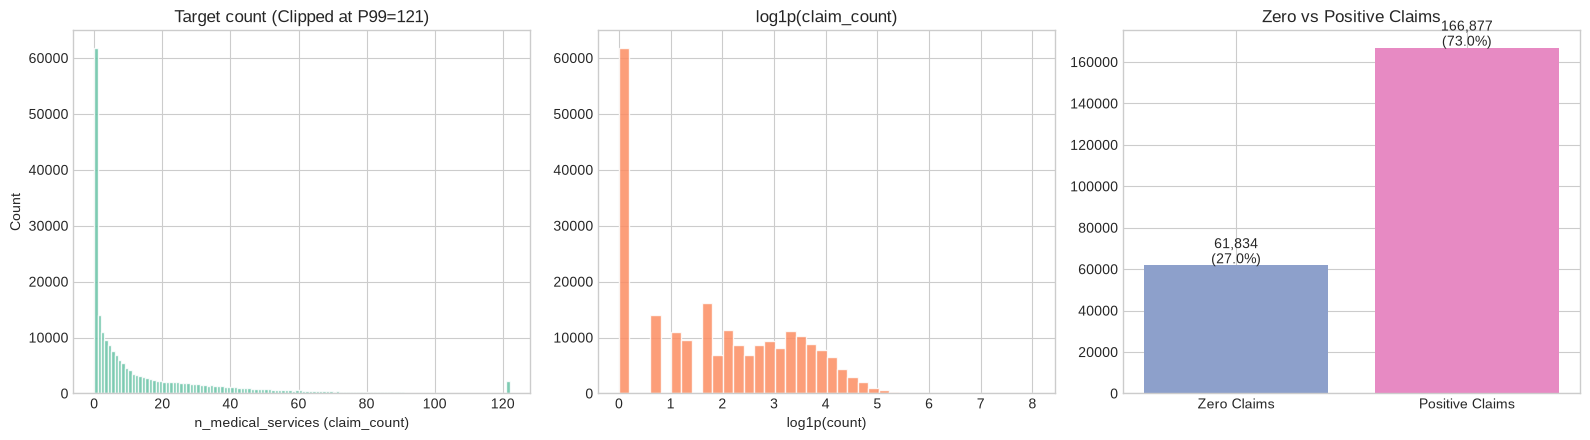

In [3]:
print("=== Target Distribution Statistics ===")
mean_cc = cc.mean()
var_cc = cc.var()
ratio = var_cc / mean_cc
zero_rate = (cc == 0).mean()
skew = cc.skew()
p95 = cc.quantile(0.95)
p99 = cc.quantile(0.99)
p999 = cc.quantile(0.999)
max_val = cc.max()

print(f"Mean                  : {mean_cc:.3f}")
print(f"Variance              : {var_cc:.3f}")
print(f"Variance/Mean (Ratio) : {ratio:.2f}  (> 1.5 indicates significant overdispersion)")
print(f"Zero-claim rate       : {zero_rate:.2%} (Percentage of records with no claims)")
print(f"Skewness              : {skew:.3f}")
print(f"P95                   : {p95}")
print(f"P99                   : {p99}")
print(f"P99.9                 : {p999}")
print(f"Max value             : {max_val}")

# Figure 1: Target Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cap = int(p99)

axes[0].hist(cc.clip(upper=cap), bins=range(0, cap+2), color=PAL[0], edgecolor="white", alpha=0.85)
axes[0].set_title(f"Target count (Clipped at P99={cap})")
axes[0].set_xlabel("n_medical_services (claim_count)")
axes[0].set_ylabel("Count")

axes[1].hist(np.log1p(cc), bins=40, color=PAL[1], edgecolor="white", alpha=0.85)
axes[1].set_title("log1p(claim_count)")
axes[1].set_xlabel("log1p(count)")

axes[2].bar(["Zero Claims", "Positive Claims"], [(cc==0).sum(), (cc>0).sum()], color=[PAL[2], PAL[3]])
axes[2].set_title("Zero vs Positive Claims")
for b, v in zip(axes[2].patches, [(cc==0).sum(), (cc>0).sum()]):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 1000, f"{v:,}\n({v/len(cc):.1%})", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / "freq_01_target_dist.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Poisson vs Negative Binomial Diagnostic

Fit thử Poisson và Negative Binomial PMF để so sánh sai số dự báo biên (đặc biệt là 0-count).

=== Fit Error Metrics (Absolute Deviation) ===
Poisson Zero Probability Error : 0.2704 (Actual: 0.2704, Pred: 4.9948e-08)
NB Zero Probability Error      : 0.0233 (Actual: 0.2704, Pred: 0.2471)
Mean Absolute Deviation (0-30) : Poisson = 0.0436, NB = 0.0029


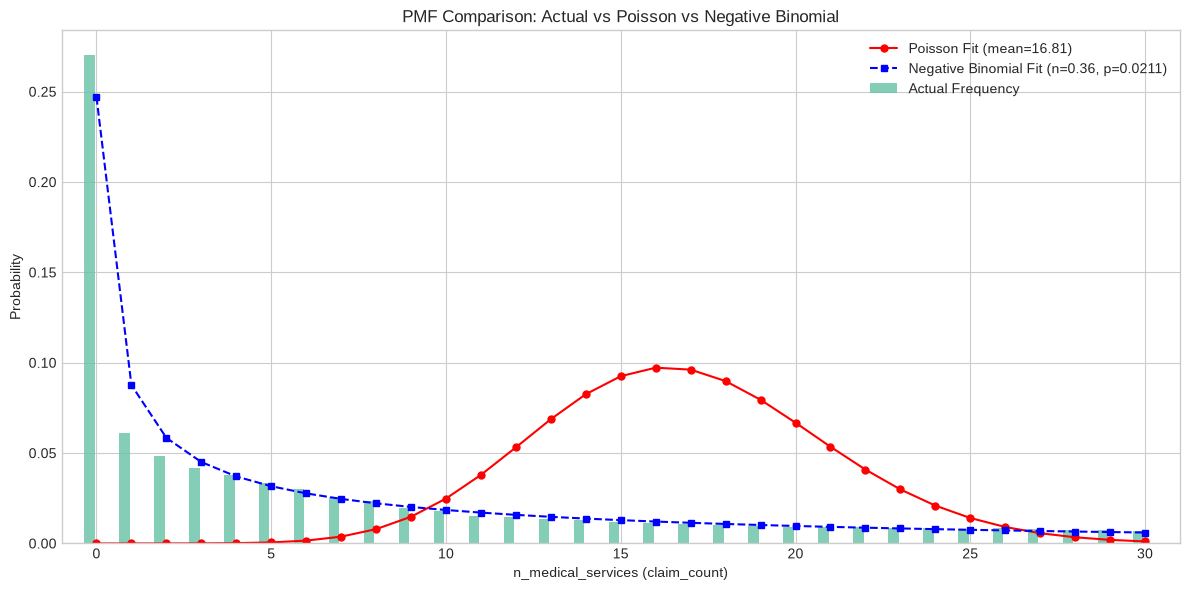

In [4]:
# Lọc bỏ outliers cực đại (>30) để biểu diễn phần lớn phân phối trực quan hơn
plot_limit = 30
x = np.arange(0, plot_limit + 1)

# 1. Thực tế
actual_counts = freq["claim_count"].value_counts(normalize=True).reindex(x, fill_value=0).values

# 2. Fit Poisson: lambda = mean
poisson_probs = poisson.pmf(x, mean_cc)

# 3. Fit Negative Binomial (Method of Moments)
# p = mean / var, n = mean^2 / (var - mean)
p_est = mean_cc / var_cc
n_est = (mean_cc ** 2) / (var_cc - mean_cc)
nbinom_probs = nbinom.pmf(x, n_est, p_est)

# Figure 2: Poisson vs NB PMF Fit
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.2, actual_counts, width=0.3, label="Actual Frequency", color=PAL[0], alpha=0.8)
ax.plot(x, poisson_probs, "ro-", lw=1.5, markersize=5, label=f"Poisson Fit (mean={mean_cc:.2f})")
ax.plot(x, nbinom_probs, "bs--", lw=1.5, markersize=5, label=f"Negative Binomial Fit (n={n_est:.2f}, p={p_est:.4f})")

ax.set_title("PMF Comparison: Actual vs Poisson vs Negative Binomial")
ax.set_xlabel("n_medical_services (claim_count)")
ax.set_ylabel("Probability")
ax.set_xlim(-1, plot_limit + 1)
ax.legend()

# Error analysis
p_err = np.abs(actual_counts - poisson_probs)
nb_err = np.abs(actual_counts - nbinom_probs)

print("=== Fit Error Metrics (Absolute Deviation) ===")
print(f"Poisson Zero Probability Error : {p_err[0]:.4f} (Actual: {actual_counts[0]:.4f}, Pred: {poisson_probs[0]:.4e})")
print(f"NB Zero Probability Error      : {nb_err[0]:.4f} (Actual: {actual_counts[0]:.4f}, Pred: {nbinom_probs[0]:.4f})")
print(f"Mean Absolute Deviation (0-30) : Poisson = {p_err.mean():.4f}, NB = {nb_err.mean():.4f}")

plt.tight_layout()
plt.savefig(FIG_DIR / "freq_02_poisson_vs_nb_fit.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Exposure and Offset Justification

Phân tích xem số lượng dịch vụ y tế có tăng tỷ lệ thuận với thời gian quan sát (exposure_time) không.

=== Exposure Buckets Analysis ===
exposure_bucket  total_obs  total_services  total_exposure  service_rate
  (-0.001, 1.0]     228711         3845156   213938.168836     17.973212


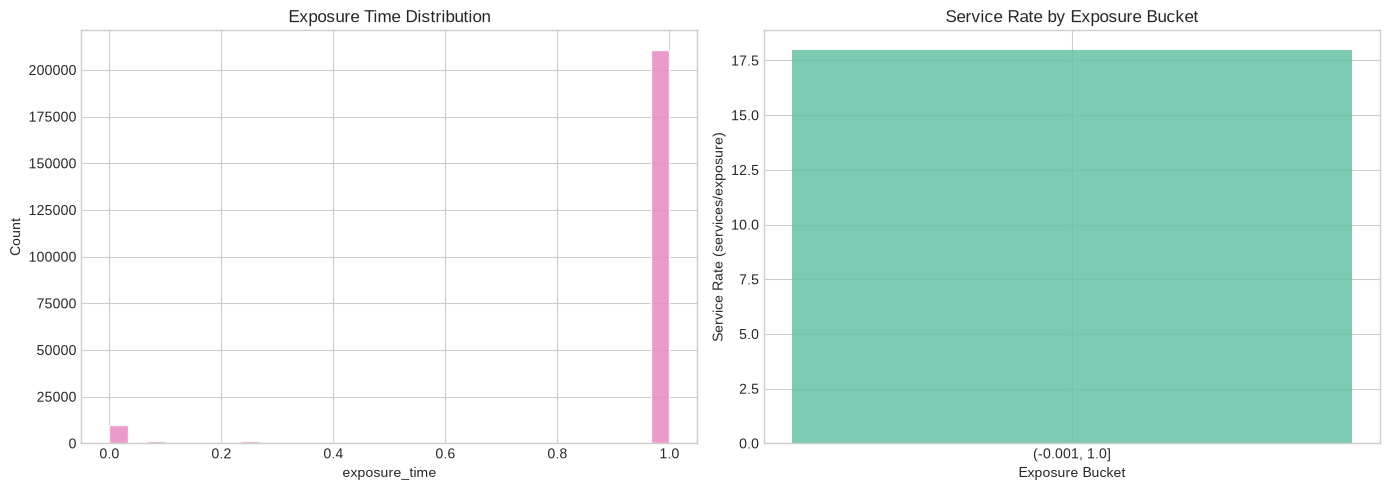

In [5]:
# Cut exposure into buckets
freq["exposure_bucket"] = pd.qcut(freq["exposure_time"], q=5, duplicates="drop")
exp_summary = freq.groupby("exposure_bucket", observed=True).agg(
    total_obs=("exposure_time", "count"),
    total_services=("claim_count", "sum"),
    total_exposure=("exposure_time", "sum")
).reset_index()
exp_summary["service_rate"] = exp_summary["total_services"] / exp_summary["total_exposure"]

print("=== Exposure Buckets Analysis ===")
print(exp_summary.to_string(index=False))

# Figure 3: Exposure Distribution and Rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(freq["exposure_time"], bins=30, color=PAL[3], edgecolor="white", alpha=0.85)
axes[0].set_title("Exposure Time Distribution")
axes[0].set_xlabel("exposure_time")
axes[0].set_ylabel("Count")

# Convert bucket intervals to strings for plotting
x_labels = [str(interval) for interval in exp_summary["exposure_bucket"]]
axes[1].bar(x_labels, exp_summary["service_rate"], color=PAL[0], alpha=0.85)
axes[1].set_title("Service Rate by Exposure Bucket")
axes[1].set_xlabel("Exposure Bucket")
axes[1].set_ylabel("Service Rate (services/exposure)")

plt.tight_layout()
plt.savefig(FIG_DIR / "freq_03_exposure_analysis.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Non-linearity and Feature Signal

Tính toán Service Rate = `sum(claim_count) / sum(exposure_time)` cho từng risk segment để xem tính tuyến tính/phi tuyến.

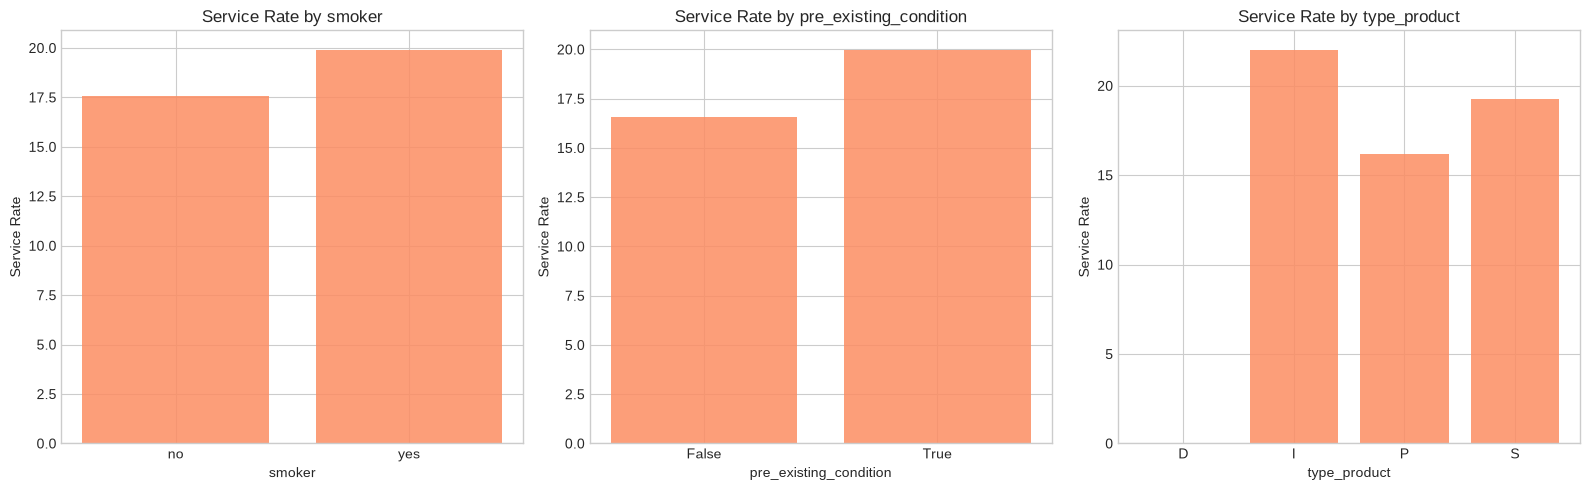

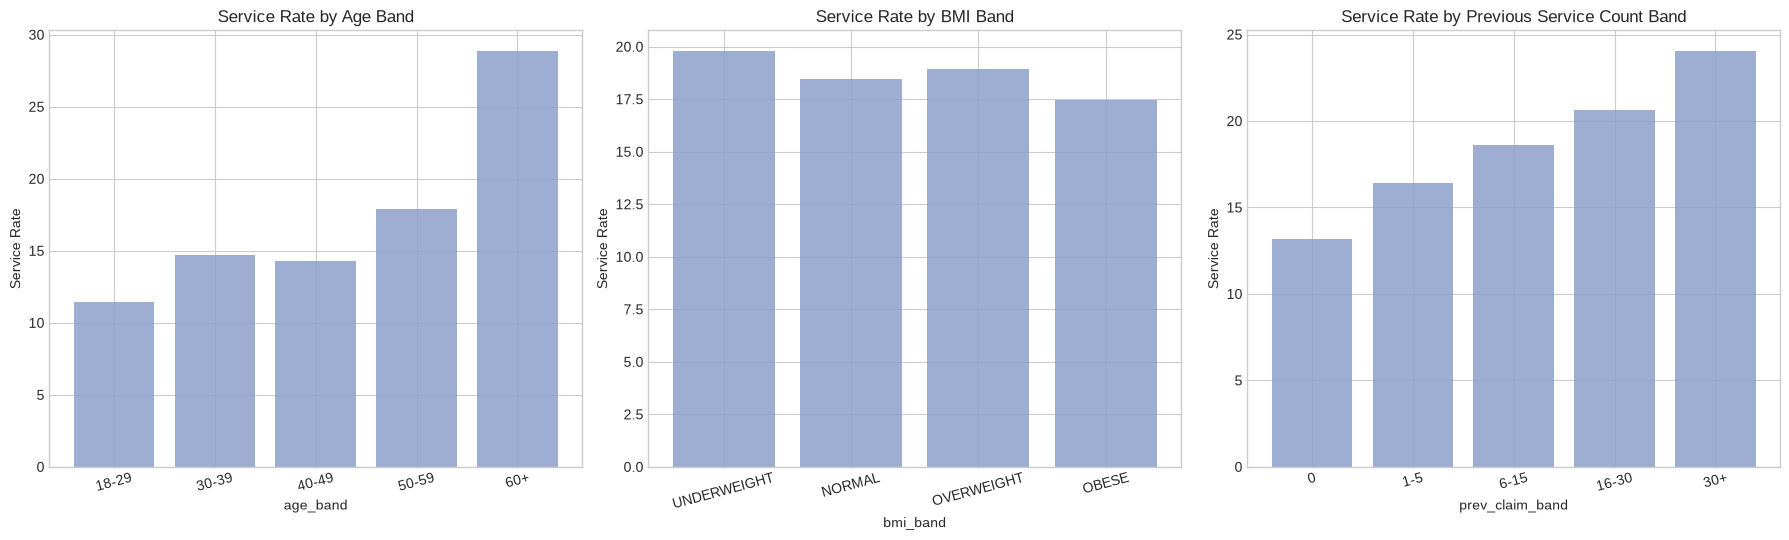

In [6]:
# Figure 4: Key Categorical Risk Segments
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cat_cols = ["smoker", "pre_existing_condition", "type_product"]

for ax, col in zip(axes, cat_cols):
    grp = freq.groupby(col, observed=True).agg(
        total_services=("claim_count", "sum"),
        total_exposure=("exposure_time", "sum")
    )
    grp["service_rate"] = grp["total_services"] / grp["total_exposure"]
    grp = grp.reset_index()
    
    ax.bar(grp[col].astype(str), grp["service_rate"], color=PAL[1], alpha=0.85)
    ax.set_title(f"Service Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Service Rate")

plt.tight_layout()
plt.savefig(FIG_DIR / "freq_04_categorical_rates.png", dpi=120, bbox_inches="tight")
plt.show()

# Figure 5: Key Binned Numerical Risk Segments
age_edges = [18, 30, 40, 50, 60, 999]
age_labels = ["18-29", "30-39", "40-49", "50-59", "60+"]
freq["age_band"] = pd.cut(freq["age"], bins=age_edges, labels=age_labels, right=False)

bmi_edges = [0, 18.5, 25, 30, 999]
bmi_labels = ["UNDERWEIGHT", "NORMAL", "OVERWEIGHT", "OBESE"]
freq["bmi_band"] = pd.cut(pd.to_numeric(freq["bmi"], errors="coerce"), bins=bmi_edges, labels=bmi_labels, right=False)

prev_edges = [-1, 0, 5, 15, 30, 9999]
prev_labels = ["0", "1-5", "6-15", "16-30", "30+"]
freq["prev_claim_band"] = pd.cut(freq["prev_claim_count"], bins=prev_edges, labels=prev_labels)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
num_bands = ["age_band", "bmi_band", "prev_claim_band"]
titles = ["Age Band", "BMI Band", "Previous Service Count Band"]

for ax, col, title in zip(axes, num_bands, titles):
    grp = freq.groupby(col, observed=True).agg(
        total_services=("claim_count", "sum"),
        total_exposure=("exposure_time", "sum")
    )
    grp["service_rate"] = grp["total_services"] / grp["total_exposure"]
    grp = grp.reset_index()
    
    ax.bar(grp[col].astype(str), grp["service_rate"], color=PAL[2], alpha=0.85)
    ax.set_title(f"Service Rate by {title}")
    ax.set_xlabel(col)
    ax.set_ylabel("Service Rate")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / "freq_05_numerical_rates.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Outlier Analysis

Xác nhận các giá trị cực đại có hợp lệ hay không.

=== Top 5 Outliers in claim_count ===
        claim_count  exposure_time  age smoker  prev_claim_cost
65902          3094       1.000000   64     no             0.00
143729         1169       0.580594   83     no           665.66
200914         1097       1.000000   64     no             0.00
111478         1029       1.000000   68    yes           887.36
53768           802       1.000000   80     no            42.50


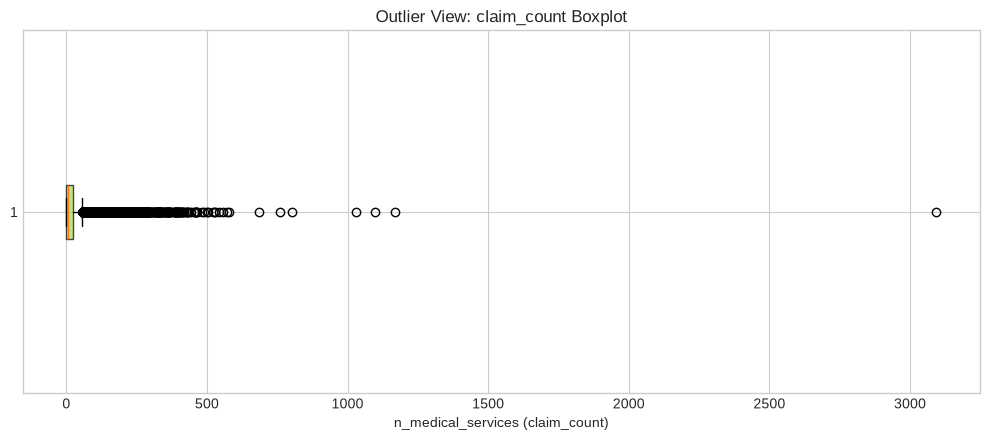

In [7]:
print("=== Top 5 Outliers in claim_count ===")
print(freq.nlargest(5, "claim_count")[["claim_count", "exposure_time", "age", "smoker", "prev_claim_cost"]])

# Figure 6: Outlier boxplot
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot(freq["claim_count"], vert=False, patch_artist=True, boxprops=dict(facecolor=PAL[4], alpha=0.7))
ax.set_title("Outlier View: claim_count Boxplot")
ax.set_xlabel("n_medical_services (claim_count)")
plt.tight_layout()
plt.savefig(FIG_DIR / "freq_06_outliers.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Model Candidates and Final Conclusion

In [8]:
conclusion_data = [
    ["Target là số đếm không âm", "Cần count model", "Poisson"],
    ["Variance/mean = 47.4", "Overdispersion mạnh", "Negative Binomial"],
    ["Target lệch phải, có đuôi dài", "GLM có thể chưa bắt hết pattern", "XGBoost Poisson"],
    ["Exposure khác nhau", "Phải mô hình hóa rate", "Offset log(exposure)"],
    ["Zero rate = 27%", "Chưa đủ bằng chứng cho zero-inflated", "Chưa dùng ZIP/ZINB"],
    ["Feature có quan hệ phi tuyến", "Cần challenger phi tuyến", "XGBoost"]
]
df_conclusion = pd.DataFrame(conclusion_data, columns=["Quan sát EDA", "Ý nghĩa mô hình", "Model đề xuất"])
print(df_conclusion.to_string(index=False))


                 Quan sát EDA                      Ý nghĩa mô hình        Model đề xuất
    Target là số đếm không âm                      Cần count model              Poisson
         Variance/mean = 47.4                  Overdispersion mạnh    Negative Binomial
Target lệch phải, có đuôi dài      GLM có thể chưa bắt hết pattern      XGBoost Poisson
           Exposure khác nhau                Phải mô hình hóa rate Offset log(exposure)
              Zero rate = 27% Chưa đủ bằng chứng cho zero-inflated   Chưa dùng ZIP/ZINB
 Feature có quan hệ phi tuyến             Cần challenger phi tuyến              XGBoost


### Conclusion\n\nThe target is a non-negative count variable representing annual medical service utilization. Its variance is approximately 47.4 times its mean, showing substantial overdispersion and violating the Poisson equidispersion assumption.\n\nPoisson GLM is therefore retained as an interpretable baseline, while Negative Binomial GLM is selected as the primary statistical candidate. XGBoost with a Poisson objective is included as a nonlinear challenger.\n\nBecause observation periods differ across policies, log(exposure_time) must be used as an offset. The observed zero proportion of 27% alone does not justify a zero-inflated model; ZIP or ZINB will only be considered if Poisson and Negative Binomial residual diagnostics show unexplained excess zeros.